# 🔍 Day 6 — Exploratory Data Analysis
## Caspian Maritime Delay-Risk Forecasting

**Week 2 begins.** Pipeline is built. Now we ask questions of the data.

Today's goals:
1. Comprehensive descriptive statistics across all variables and cities
2. Distribution shapes — are things Gaussian? Skewed? Bimodal?
3. Time-series structure — trends, seasonality, residual variability
4. Cross-city patterns — how correlated are the five ports?
5. Surface concrete questions for Day 7's hypothesis tests

**Anchor city for single-city tasks**: Baku (largest Caspian port, primary stakeholder reference)
**Date range**: 2015-01-01 → 2024-12-31 (10 full years)

---

## 0 — Setup

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.tsa.seasonal import seasonal_decompose

warnings.filterwarnings('ignore')

REPO_ROOT = Path('..').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.database import get_connection, run_query
from src.config import PATHS, CITIES

# Output directory for figures
FIGURES_DIR = REPO_ROOT / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Plot styling
sns.set_theme(style='whitegrid', context='notebook', palette='deep')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'

# Anchor city + city order (kept consistent across all plots)
ANCHOR_CITY = 'Baku'
CITY_ORDER = ['Baku', 'Aktau', 'Anzali', 'Turkmenbashi', 'Makhachkala']
CITY_PALETTE = dict(zip(CITY_ORDER, sns.color_palette('deep', n_colors=5)))

DB_PATH = PATHS['repo_root'] / 'data' / 'caspian_weather.duckdb'
conn = get_connection(DB_PATH)
print(f'✅ Connected to {DB_PATH}')
print(f'   Anchor city: {ANCHOR_CITY}')
print(f'   Figures will save to: {FIGURES_DIR}')

✅ Connected to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\data\caspian_weather.duckdb
   Anchor city: Baku
   Figures will save to: C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\figures


In [2]:
# Load the analytics layer once into pandas — fast, easy to slice
df = conn.execute('''
    SELECT * FROM analytics.daily_enriched ORDER BY city, date
''').fetchdf()
df['date'] = pd.to_datetime(df['date'])

monthly = conn.execute('''
    SELECT * FROM analytics.monthly_summary ORDER BY city, year, month
''').fetchdf()

print(f'Daily rows:   {len(df):>7,}  ({df["city"].nunique()} cities)')
print(f'Monthly rows: {len(monthly):>7,}')
print(f'Date range:   {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Columns ({len(df.columns)}): {list(df.columns)[:15]}, ...')

Daily rows:    20,680  (5 cities)
Monthly rows:     680
Date range:   2015-01-01 → 2026-04-28
Columns (72): ['city', 'date', 'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean', 'apparent_temperature_mean', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_direction_10m_dominant', 'precipitation_sum', 'rain_sum', 'snowfall_sum', 'weather_code', 'relative_humidity_2m_mean', 'dew_point_2m_mean'], ...


---
## 1 — Descriptive Statistics

### 1.1 Summary table

Per (city, variable): count, mean, std, min, Q1, median, Q3, max, skewness, kurtosis.

Variables that matter most for delay-risk: temperature, wind, precipitation, visibility, wave height.

In [3]:
core_vars = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'wind_speed_10m_max', 'wind_gusts_10m_max',
    'precipitation_sum', 'snowfall_sum',
    'relative_humidity_2m_mean', 'surface_pressure_mean',
    'visibility_mean', 'wave_height',
]

def describe_with_shape(s):
    """Standard describe() + skewness + kurtosis."""
    s = s.dropna()
    if len(s) == 0:
        return pd.Series({k: np.nan for k in
                          ['count','mean','std','min','q25','median','q75','max','skew','kurt']})
    return pd.Series({
        'count':  len(s),
        'mean':   s.mean(),
        'std':    s.std(),
        'min':    s.min(),
        'q25':    s.quantile(0.25),
        'median': s.median(),
        'q75':    s.quantile(0.75),
        'max':    s.max(),
        'skew':   stats.skew(s),
        'kurt':   stats.kurtosis(s),  # excess kurtosis (Gaussian = 0)
    })

summary_rows = []
for city in CITY_ORDER:
    for var in core_vars:
        if var not in df.columns:
            continue
        stats_row = describe_with_shape(df[df['city'] == city][var])
        stats_row['city'] = city
        stats_row['variable'] = var
        summary_rows.append(stats_row)

summary_df = pd.DataFrame(summary_rows).set_index(['city', 'variable'])
summary_df = summary_df[['count','mean','std','min','q25','median','q75','max','skew','kurt']]
summary_df.round(2).head(22)

count      mean       std      min  \
city  variable                                                         
Baku  temperature_2m_max         4136.0     18.87      9.23    -1.00   
      temperature_2m_min         4136.0     12.18      7.71    -7.20   
      temperature_2m_mean        4136.0     15.37      8.33    -3.30   
      wind_speed_10m_max         4136.0     25.60      9.54     6.30   
      wind_gusts_10m_max         4136.0     45.99     14.70    14.80   
      precipitation_sum          4136.0      0.85      2.59     0.00   
      snowfall_sum               4136.0      0.03      0.27     0.00   
      relative_humidity_2m_mean  4136.0     73.48     11.13    32.00   
      surface_pressure_mean      4136.0   1013.28      7.21   992.50   
      visibility_mean            4136.0  26240.21   8202.64  2063.30   
      wave_height                4136.0      1.15      0.86     0.08   
Aktau temperature_2m_max         4136.0     17.60     11.08    -9.30   
      temperature_2m_min         4136.0     10.28      9.83   -16.10   
      temperature_2m_mean        4136.0     13.84     10.47   -12.80   
      wind_speed_10m_max         4136.0     26.84      7.90     6.20   
      wind_gusts_10m_max         4136.0     42.62     11.50    12.60   
      precipitation_sum          4136.0      0.57      2.07     0.00   
      snowfall_sum               4136.0      0.05      0.39     0.00   
      relative_humidity_2m_mean  4136.0     62.32     18.73    12.00   
      surface_pressure_mean      4136.0   1017.39      7.97   995.50   
      visibility_mean            4136.0  27652.08  11906.25  2613.30   
      wave_height                4136.0      1.12      0.62     0.09   

                                      q25    median       q75       max  \
city  variable                                                            
Baku  temperature_2m_max            10.60     18.00     27.00     40.50   
      temperature_2m_min             5.50     11.40     19.20     28.30   
      temperature_2m_mean            7.80     14.60     23.20     32.40   
      wind_speed_10m_max            18.30     24.10     31.60     65.90   
      wind_gusts_10m_max            35.30     43.60     54.70    103.00   
      precipitation_sum              0.00      0.00      0.30     30.00   
      snowfall_sum                   0.00      0.00      0.00      6.02   
      relative_humidity_2m_mean     66.00     74.00     82.00     97.00   
      surface_pressure_mean       1007.90   1012.60   1018.10   1041.50   
      visibility_mean            24140.00  24140.00  24140.00  74984.20   
      wave_height                    0.51      0.85      1.61      5.46   
Aktau temperature_2m_max             8.10     17.10     27.30     42.40   
      temperature_2m_min             2.10      9.70     19.10     29.90   
      temperature_2m_mean            5.00     13.10     23.22     35.40   
      wind_speed_10m_max            21.10     26.00     31.80     70.10   
      wind_gusts_10m_max            34.60     41.80     49.70    101.90   
      precipitation_sum              0.00      0.00      0.10     25.00   
      snowfall_sum                   0.00      0.00      0.00     10.85   
      relative_humidity_2m_mean     48.00     66.00     78.00     97.00   
      surface_pressure_mean       1011.58   1016.60   1022.60   1050.90   
      visibility_mean            24140.00  24140.00  24140.00  84544.20   
      wave_height                    0.66      0.98      1.46      5.32   

                                  skew    kurt  
city  variable                                  
Baku  temperature_2m_max          0.18   -1.14  
      temperature_2m_min          0.11   -1.20  
      temperature_2m_mean         0.15   -1.26  
      wind_speed_10m_max          0.70    0.20  
      wind_gusts_10m_max          0.70    0.28  
      precipitation_sum           5.57   41.30  
      snowfall_sum               12.75  193.11  
      relative_humidity_2m_mean  -0.43   -0.34  
      surface_

In [4]:
# Quick read on shape: which variables are most non-Gaussian?
shape_summary = (
    summary_df.groupby('variable')[['skew', 'kurt']]
      .mean()
      .sort_values('skew', key=abs, ascending=False)
      .round(2)
)
print('Average |skew| and excess-kurtosis across cities')
print('(Gaussian → skew ≈ 0, kurt ≈ 0)')
print()
shape_summary

Average |skew| and excess-kurtosis across cities
(Gaussian → skew ≈ 0, kurt ≈ 0)



,skew,kurt
variable,,
snowfall_sum,14.59,262.13
precipitation_sum,5.52,42.61
visibility_mean,2.91,11.48
wave_height,1.62,3.90
wind_speed_10m_max,0.75,0.70
wind_gusts_10m_max,0.71,0.64
relative_humidity_2m_mean,-0.60,0.02
surface_pressure_mean,0.37,-0.17
temperature_2m_max,0.09,-1.16


### 1.2 Yearly trends

Average temperature, total precipitation, and max wind speed per year per city.

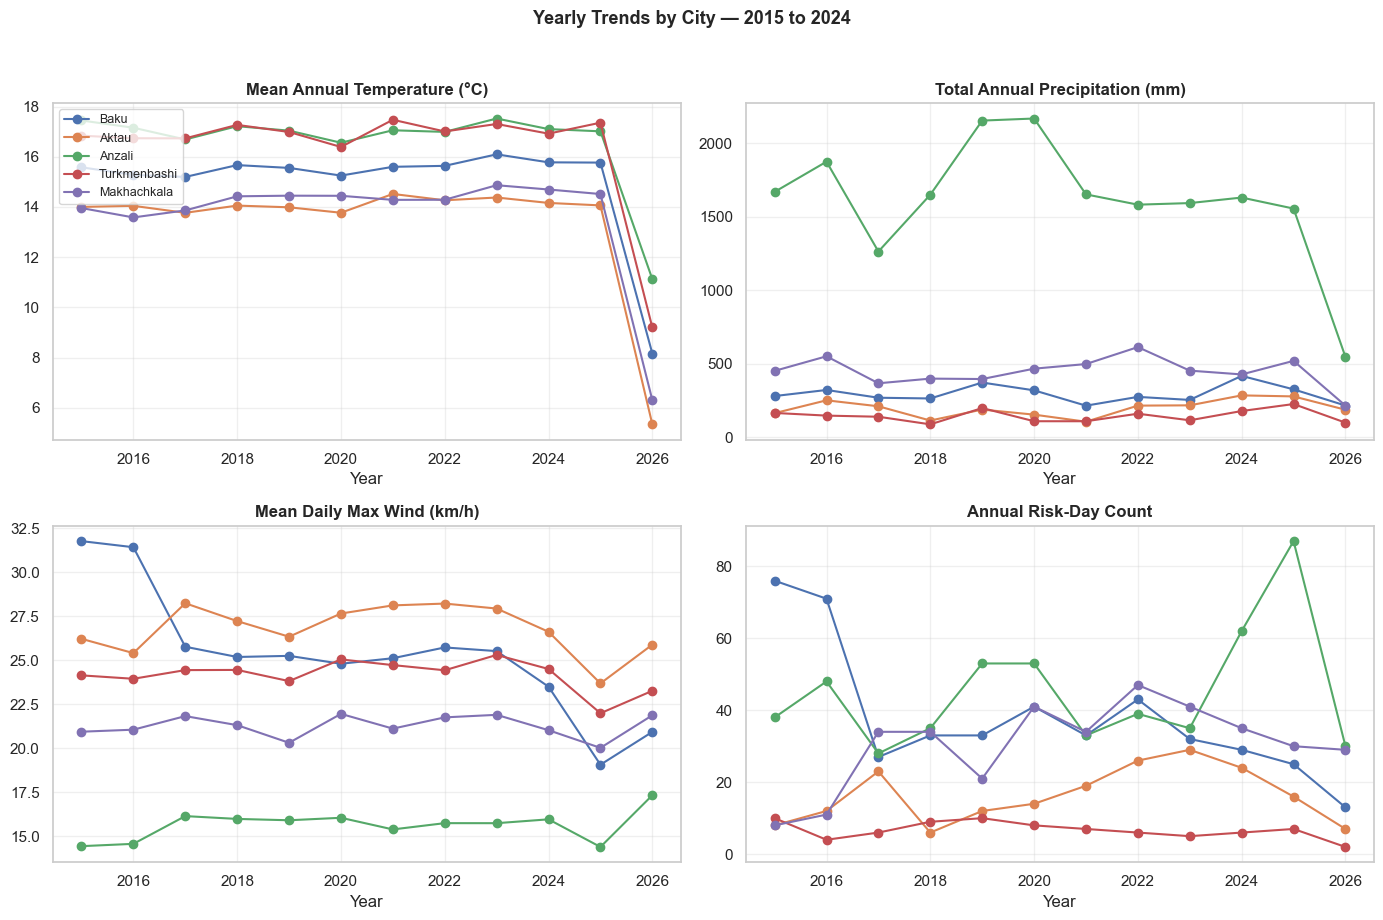

In [5]:
yearly = (
    df.groupby(['city', 'year'])
      .agg(
          mean_temp=('temperature_2m_mean', 'mean'),
          total_precip=('precipitation_sum', 'sum'),
          max_wind=('wind_speed_10m_max', 'max'),
          mean_wind=('wind_speed_10m_max', 'mean'),
          risk_days=('is_risk_day', 'sum'),
      )
      .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
metrics = [
    ('mean_temp',   'Mean Annual Temperature (°C)'),
    ('total_precip','Total Annual Precipitation (mm)'),
    ('mean_wind',   'Mean Daily Max Wind (km/h)'),
    ('risk_days',   'Annual Risk-Day Count'),
]
for ax, (col, title) in zip(axes.flat, metrics):
    for city in CITY_ORDER:
        sub = yearly[yearly['city'] == city]
        ax.plot(sub['year'], sub[col], marker='o', linewidth=1.5,
                color=CITY_PALETTE[city], label=city)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.grid(alpha=0.3)
axes[0, 0].legend(loc='upper left', fontsize=9)
fig.suptitle('Yearly Trends by City — 2015 to 2024', fontsize=13, fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_yearly_trends.png')
plt.show()

### 1.3 Monthly profiles

Mean and standard deviation of temperature, wind, and precipitation by calendar month.

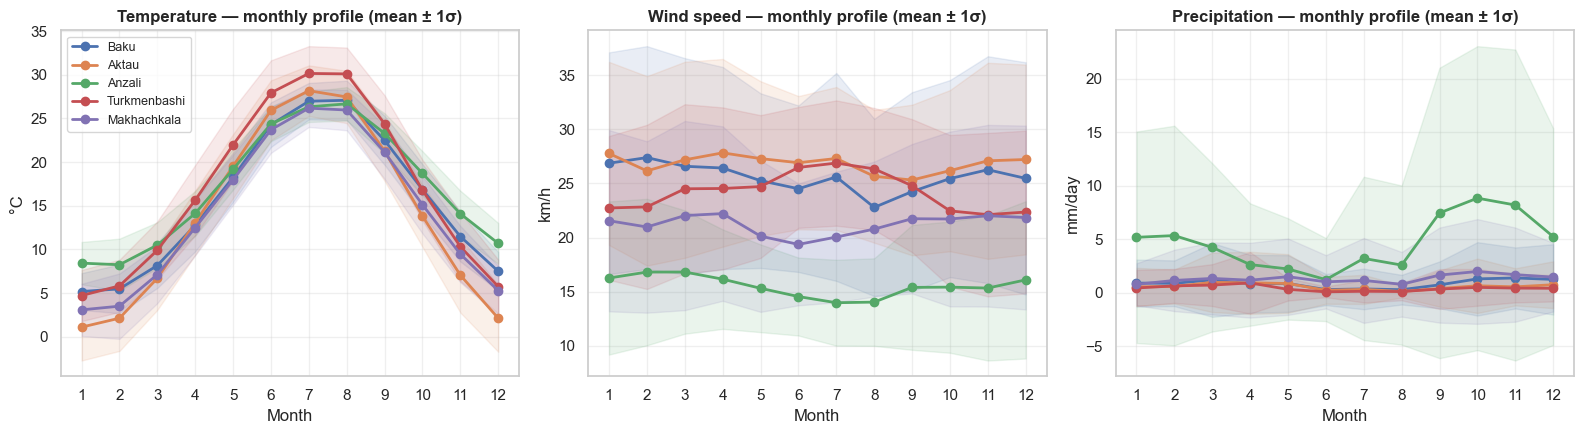


Most variable month per city (highest temperature σ):
              month  temp_std
city                         
Aktau            11      4.29
Anzali            2      2.99
Baku              4      3.00
Makhachkala       2      3.75
Turkmenbashi      5      4.14


In [6]:
monthly_profile = (
    df.groupby(['city', 'month'])
      .agg(
          temp_mean=('temperature_2m_mean', 'mean'),
          temp_std=('temperature_2m_mean', 'std'),
          wind_mean=('wind_speed_10m_max', 'mean'),
          wind_std=('wind_speed_10m_max', 'std'),
          precip_mean=('precipitation_sum', 'mean'),
          precip_std=('precipitation_sum', 'std'),
      )
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col_mean, col_std, title, ylabel) in zip(axes, [
    ('temp_mean',   'temp_std',   'Temperature',  '°C'),
    ('wind_mean',   'wind_std',   'Wind speed',   'km/h'),
    ('precip_mean', 'precip_std', 'Precipitation','mm/day'),
]):
    for city in CITY_ORDER:
        sub = monthly_profile[monthly_profile['city'] == city]
        ax.plot(sub['month'], sub[col_mean], marker='o', linewidth=2,
                color=CITY_PALETTE[city], label=city)
        ax.fill_between(sub['month'],
                        sub[col_mean] - sub[col_std],
                        sub[col_mean] + sub[col_std],
                        alpha=0.12, color=CITY_PALETTE[city])
    ax.set_title(f'{title} — monthly profile (mean ± 1σ)', fontweight='bold')
    ax.set_xlabel('Month')
    ax.set_ylabel(ylabel)
    ax.set_xticks(range(1, 13))
    ax.grid(alpha=0.3)
axes[0].legend(loc='upper left', fontsize=9)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_monthly_profiles.png')
plt.show()

# Print which month has the highest variability
var_by_month = (
    df.groupby(['city', 'month'])['temperature_2m_mean']
      .std()
      .reset_index(name='temp_std')
)
most_variable = var_by_month.loc[var_by_month.groupby('city')['temp_std'].idxmax()]
print('\nMost variable month per city (highest temperature σ):')
print(most_variable.set_index('city')[['month', 'temp_std']].round(2))

### 1.4 Extreme values

Top 10 hottest, coldest, wettest, windiest days across all cities.

In [7]:
def top10(metric, col, ascending=False):
    label = 'Coldest' if ascending else metric
    return (df[['city', 'date', col]]
            .sort_values(col, ascending=ascending)
            .head(10)
            .assign(rank=range(1, 11))
            .reset_index(drop=True))

print('🔥 Top 10 HOTTEST days')
print(top10('Hottest', 'temperature_2m_max').to_string(index=False))
print('\n❄️  Top 10 COLDEST days')
print(top10('Coldest', 'temperature_2m_min', ascending=True).to_string(index=False))
print('\n💨 Top 10 WINDIEST days')
print(top10('Windiest', 'wind_speed_10m_max').to_string(index=False))
print('\n🌧  Top 10 WETTEST days')
print(top10('Wettest', 'precipitation_sum').to_string(index=False))

🔥 Top 10 HOTTEST days
        city       date  temperature_2m_max  rank
Turkmenbashi 2018-07-01                44.2     1
Turkmenbashi 2021-08-09                43.0     2
Turkmenbashi 2021-07-05                42.8     3
Turkmenbashi 2018-07-13                42.7     4
       Aktau 2022-06-27                42.4     5
Turkmenbashi 2023-07-09                42.0     6
Turkmenbashi 2018-06-30                42.0     7
       Aktau 2023-08-04                41.8     8
Turkmenbashi 2017-08-08                41.7     9
Turkmenbashi 2024-07-09                41.5    10

❄️  Top 10 COLDEST days
       city       date  temperature_2m_min  rank
      Aktau 2023-01-11               -16.1     1
      Aktau 2023-01-10               -14.9     2
      Aktau 2026-01-27               -14.5     3
      Aktau 2017-02-09               -14.5     4
Makhachkala 2021-02-24               -14.0     5
Makhachkala 2025-03-02               -13.2     6
      Aktau 2021-02-24               -13.1     7
      Aktau

---
## 2 — Distribution Analysis

### 2.1 Temperature histograms — overlaid by city

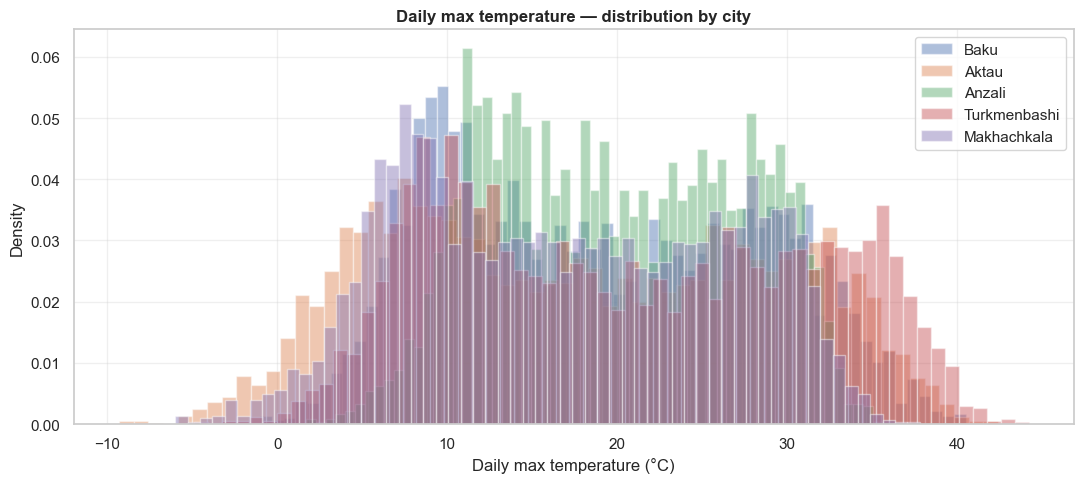


Look for bimodality — these are 10-year distributions, so a winter peak
and a summer peak should be visible. Anzali (subtropical) should be unimodal.


In [8]:
fig, ax = plt.subplots(figsize=(11, 5))
for city in CITY_ORDER:
    sub = df[df['city'] == city]['temperature_2m_max'].dropna()
    ax.hist(sub, bins=60, alpha=0.45, label=city,
            color=CITY_PALETTE[city], density=True)
ax.set_title('Daily max temperature — distribution by city',
             fontweight='bold')
ax.set_xlabel('Daily max temperature (°C)')
ax.set_ylabel('Density')
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_temp_distribution_overlay.png')
plt.show()

# Note: bimodality (two humps) is expected — winter mode + summer mode
print("\nLook for bimodality — these are 10-year distributions, so a winter peak")
print("and a summer peak should be visible. Anzali (subtropical) should be unimodal.")

### 2.2 Box plots — temperature by season

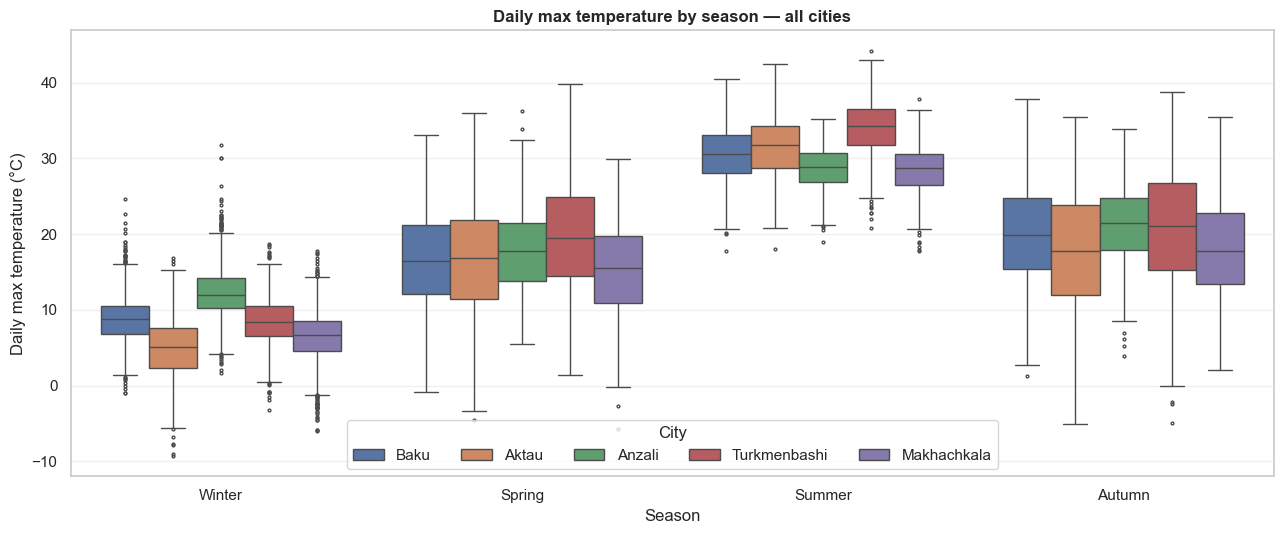

In [9]:
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
fig, ax = plt.subplots(figsize=(13, 5.5))
sns.boxplot(
    data=df, x='season', y='temperature_2m_max', hue='city',
    order=season_order, hue_order=CITY_ORDER,
    palette=[CITY_PALETTE[c] for c in CITY_ORDER],   # ← list, not dict
    ax=ax, fliersize=2,
    legend='auto',
)
ax.set_title('Daily max temperature by season — all cities',
             fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Daily max temperature (°C)')
ax.legend(title='City', loc='lower center', ncol=5)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_temp_by_season_boxplot.png')
plt.show()

### 2.3 Violin plots — precipitation by city (log scale)

Precipitation is heavily right-skewed (many zeros, long tail). Log scale + small offset reveals the shape.

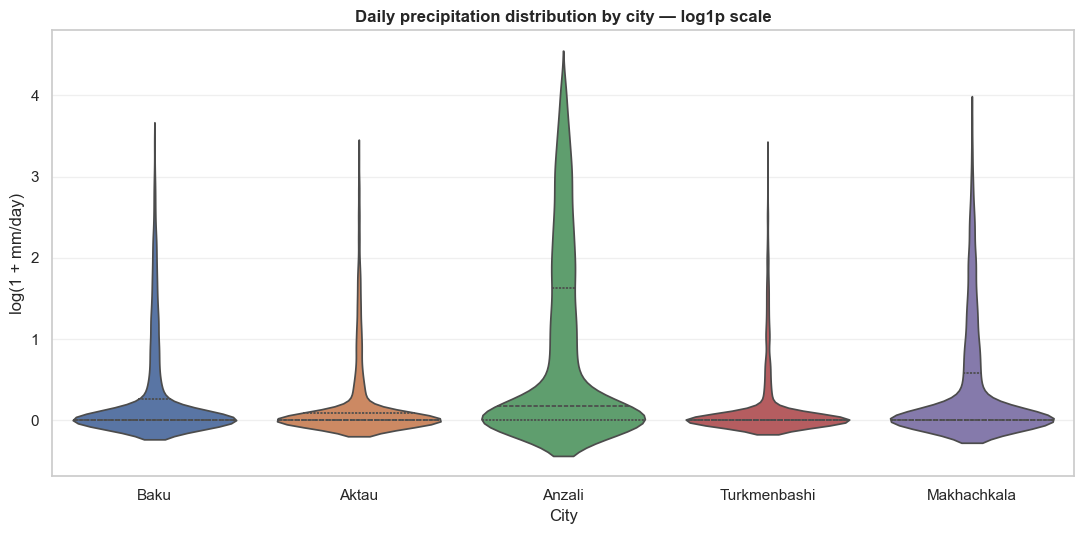


Fraction of dry days (precip < 0.1 mm) by city:
city
Baku            66.3%
Aktau           72.9%
Anzali          46.2%
Turkmenbashi    77.9%
Makhachkala     60.2%
Name: dry, dtype: object


In [10]:
fig, ax = plt.subplots(figsize=(11, 5.5))
df_plot = df.copy()
df_plot['precip_log1p'] = np.log1p(df_plot['precipitation_sum'])  # log(1+x) handles zeros
sns.violinplot(
    data=df_plot, x='city', y='precip_log1p',
    order=CITY_ORDER, palette=CITY_PALETTE,
    ax=ax, inner='quartile',
)
ax.set_title('Daily precipitation distribution by city — log1p scale',
             fontweight='bold')
ax.set_xlabel('City')
ax.set_ylabel('log(1 + mm/day)')
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_precip_violin.png')
plt.show()

# Useful sanity check: fraction of dry days per city
dry_share = (
    df.assign(dry=df['precipitation_sum'] < 0.1)
      .groupby('city')['dry'].mean().reindex(CITY_ORDER)
)
print('\nFraction of dry days (precip < 0.1 mm) by city:')
print((dry_share * 100).round(1).astype(str) + '%')

### 2.4 QQ-plots — normality check for temperature

If the points hug the red line, the distribution is approximately Gaussian. Departures at the tails reveal heavy/light tails. Important for Day 7 — t-tests assume normality (or large sample sizes via CLT).

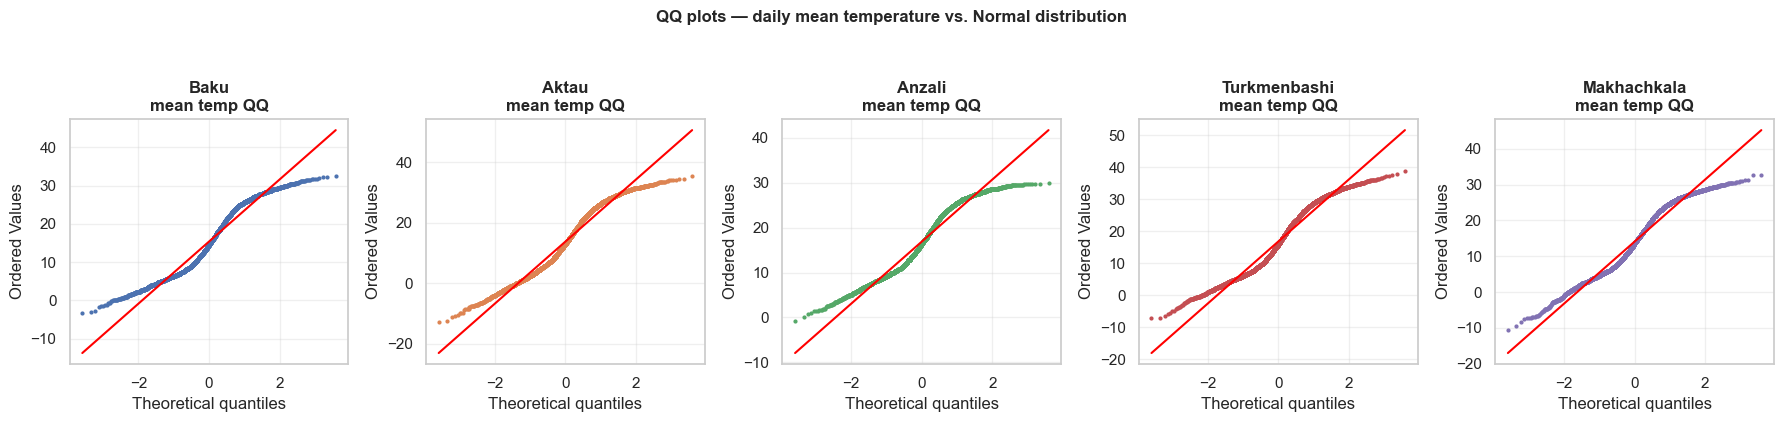


Shapiro-Wilk normality test on mean daily temperature:
(With N≈3650, even tiny deviations will reject. Treat as directional.)
  Baku           W = 0.9471, p = 3.45e-36
  Aktau          W = 0.9626, p = 1.97e-31
  Anzali         W = 0.9527, p = 1.23e-34
  Turkmenbashi   W = 0.9560, p = 1.29e-33
  Makhachkala    W = 0.9595, p = 1.72e-32


In [11]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, city in zip(axes, CITY_ORDER):
    sub = df[df['city'] == city]['temperature_2m_mean'].dropna()
    stats.probplot(sub, dist='norm', plot=ax)
    ax.set_title(f'{city}\nmean temp QQ', fontweight='bold')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[0].set_color(CITY_PALETTE[city])
    ax.get_lines()[1].set_color('red')
    ax.grid(alpha=0.3)
fig.suptitle('QQ plots — daily mean temperature vs. Normal distribution',
             fontsize=12, fontweight='bold', y=1.05)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_qqplots_temperature.png')
plt.show()

# Formal test for completeness — Shapiro-Wilk (note: with N=3650 it's almost
# guaranteed to reject; use as a directional indicator only)
print('\nShapiro-Wilk normality test on mean daily temperature:')
print('(With N≈3650, even tiny deviations will reject. Treat as directional.)')
for city in CITY_ORDER:
    sub = df[df['city'] == city]['temperature_2m_mean'].dropna().sample(
        min(5000, len(df[df['city'] == city])), random_state=42)
    W, p = stats.shapiro(sub)
    print(f'  {city:<14} W = {W:.4f}, p = {p:.2e}')

---
## 3 — Time-Series Exploration (anchor city: Baku)

### 3.1 10-year time series + 30-day rolling average

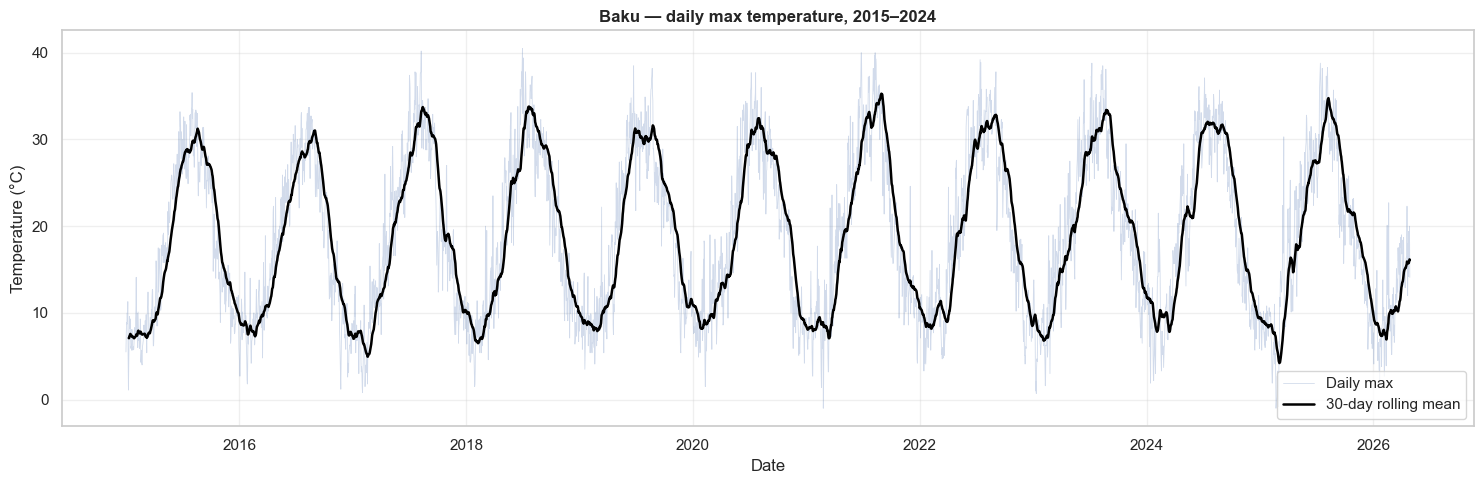

In [12]:
baku = df[df['city'] == ANCHOR_CITY].copy().sort_values('date')
baku['temp_30d'] = baku['temperature_2m_max'].rolling(30, min_periods=10).mean()

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(baku['date'], baku['temperature_2m_max'],
        color=CITY_PALETTE[ANCHOR_CITY], alpha=0.25, linewidth=0.6,
        label='Daily max')
ax.plot(baku['date'], baku['temp_30d'],
        color='black', linewidth=1.8, label='30-day rolling mean')
ax.set_title(f'{ANCHOR_CITY} — daily max temperature, 2015–2024',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_timeseries_{ANCHOR_CITY.lower()}.png')
plt.show()

### 3.2 Seasonal decomposition

Decompose Baku's temperature into trend, annual seasonal cycle, and residual using `statsmodels`.

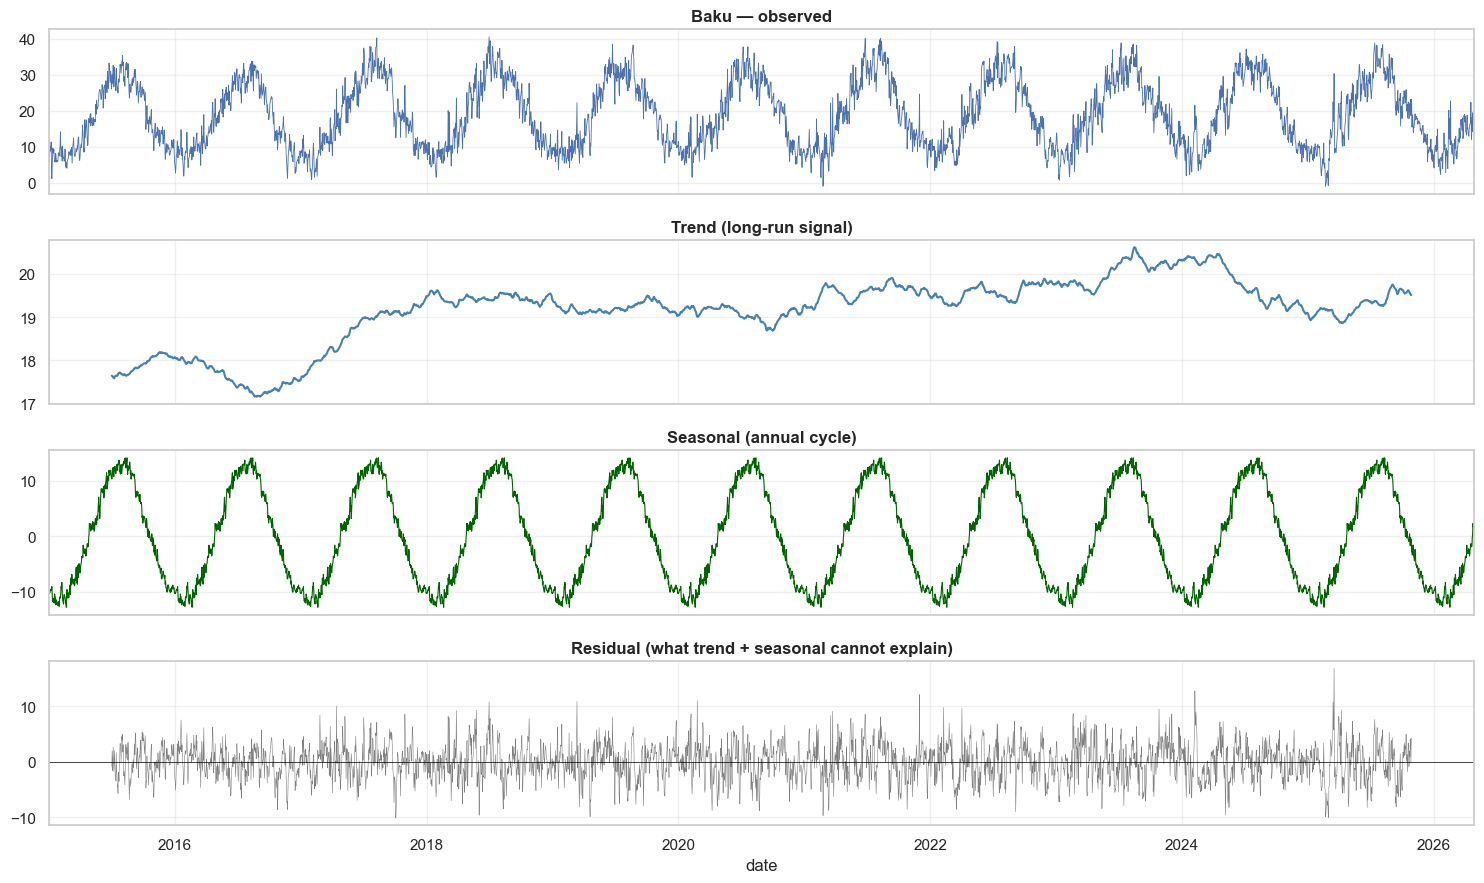


Trend change over 10 years: +1.87 °C
Seasonal amplitude (peak-to-trough): 26.9 °C
Residual σ: 3.18 °C  ← what a daily forecast would have to beat


In [13]:
ts = baku.set_index('date')['temperature_2m_max'].asfreq('D')
ts = ts.interpolate(limit=3)  # tiny gap fill so decompose doesn't crash
decomp = seasonal_decompose(ts.dropna(), model='additive', period=365)

fig, axes = plt.subplots(4, 1, figsize=(15, 9), sharex=True)
decomp.observed.plot(ax=axes[0], color=CITY_PALETTE[ANCHOR_CITY], linewidth=0.6)
axes[0].set_title(f'{ANCHOR_CITY} — observed', fontweight='bold')
decomp.trend.plot(ax=axes[1], color='steelblue', linewidth=1.5)
axes[1].set_title('Trend (long-run signal)', fontweight='bold')
decomp.seasonal.plot(ax=axes[2], color='darkgreen', linewidth=0.8)
axes[2].set_title('Seasonal (annual cycle)', fontweight='bold')
decomp.resid.plot(ax=axes[3], color='gray', linewidth=0.4)
axes[3].set_title('Residual (what trend + seasonal cannot explain)', fontweight='bold')
axes[3].axhline(0, color='black', linewidth=0.5)
for ax in axes:
    ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_decomposition_{ANCHOR_CITY.lower()}.png')
plt.show()

# Some stats for interpretation
trend_change = decomp.trend.dropna().iloc[-1] - decomp.trend.dropna().iloc[0]
seasonal_amp = decomp.seasonal.max() - decomp.seasonal.min()
resid_std = decomp.resid.std()
print(f'\nTrend change over 10 years: {trend_change:+.2f} °C')
print(f'Seasonal amplitude (peak-to-trough): {seasonal_amp:.1f} °C')
print(f'Residual σ: {resid_std:.2f} °C  ← what a daily forecast would have to beat')

### 3.3 Year-over-year overlay

All 10 years of Baku's temperature laid on a common day-of-year axis.

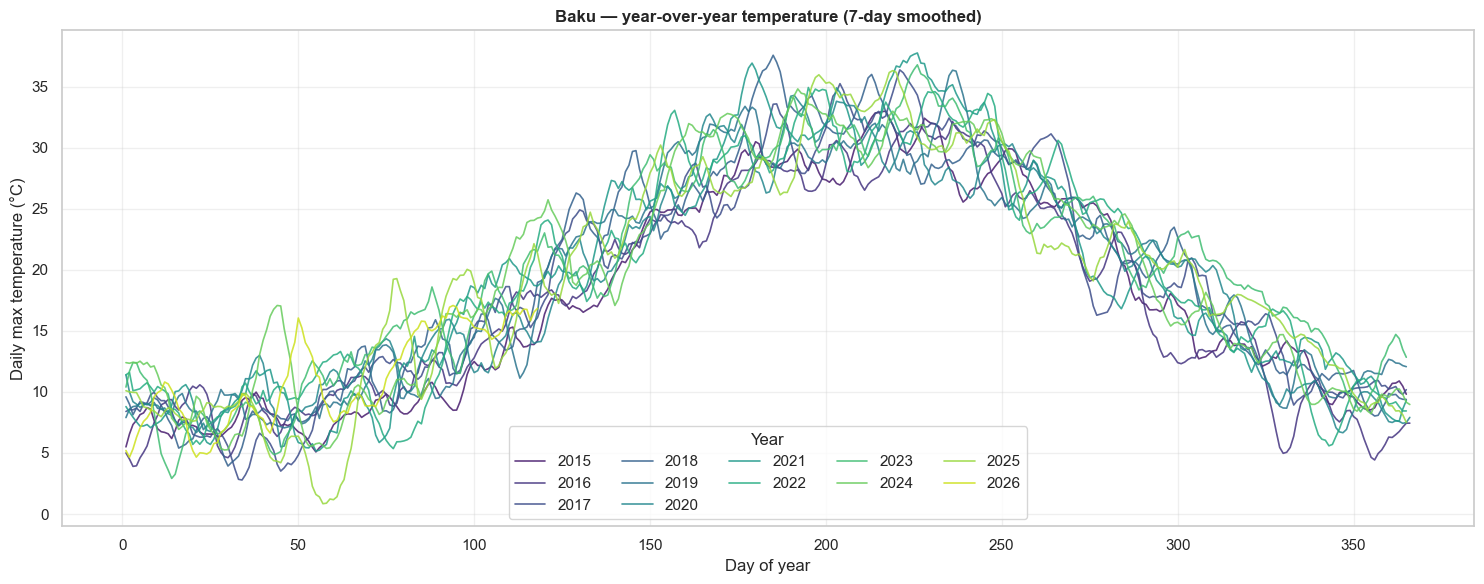

In [14]:
yoy = baku[['date', 'temperature_2m_max']].copy()
yoy['year'] = yoy['date'].dt.year
yoy['doy']  = yoy['date'].dt.dayofyear

n_years = yoy['year'].nunique()
year_palette = sns.color_palette('viridis', n_colors=n_years)

fig, ax = plt.subplots(figsize=(15, 6))
for i, (yr, sub) in enumerate(yoy.groupby('year')):
    ax.plot(sub['doy'], sub['temperature_2m_max'].rolling(7, min_periods=1).mean(),
            color=year_palette[i], linewidth=1.2, alpha=0.85, label=str(yr))
ax.set_title(f'{ANCHOR_CITY} — year-over-year temperature (7-day smoothed)',
             fontweight='bold')
ax.set_xlabel('Day of year')
ax.set_ylabel('Daily max temperature (°C)')
ax.legend(title='Year', ncol=5, loc='lower center')
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_yoy_{ANCHOR_CITY.lower()}.png')
plt.show()

### 3.4 Calendar heatmap (year × day-of-year) for Baku temperature

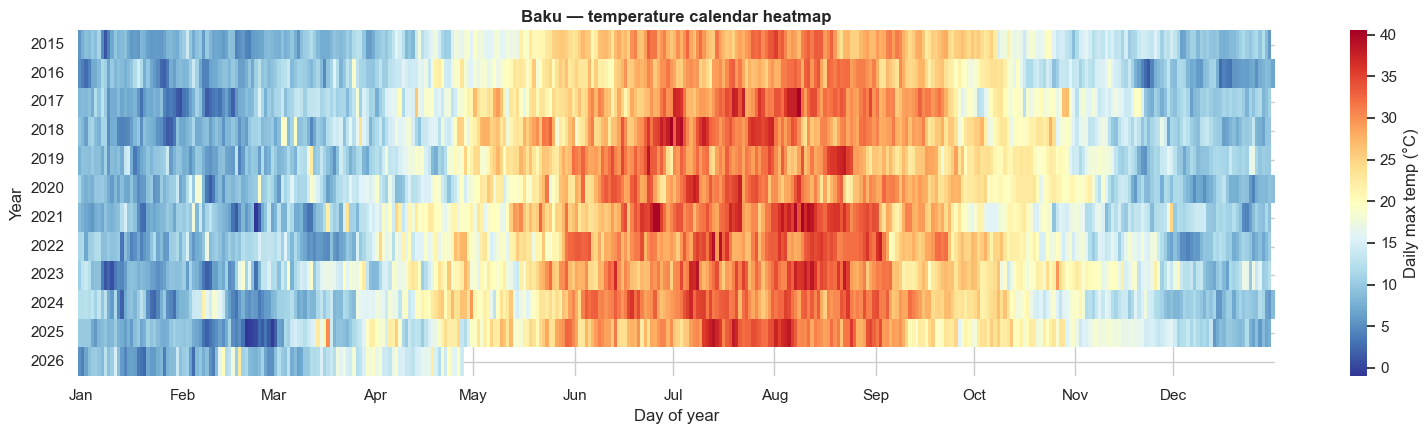

In [15]:
heat = baku.pivot_table(
    index='year', columns=baku['date'].dt.dayofyear,
    values='temperature_2m_max', aggfunc='mean',
)

fig, ax = plt.subplots(figsize=(16, 4.5))
sns.heatmap(
    heat, ax=ax, cmap='RdYlBu_r',
    cbar_kws={'label': 'Daily max temp (°C)'},
    xticklabels=False,
)
# Tick every ~30 days
month_starts = [1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_xticks(month_starts)
ax.set_xticklabels(month_labels)
ax.set_title(f'{ANCHOR_CITY} — temperature calendar heatmap',
             fontweight='bold')
ax.set_xlabel('Day of year')
ax.set_ylabel('Year')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_calendar_heatmap_{ANCHOR_CITY.lower()}.png')
plt.show()

---
## 4 — Cross-City Comparison

### 4.1 All cities, one variable, one year

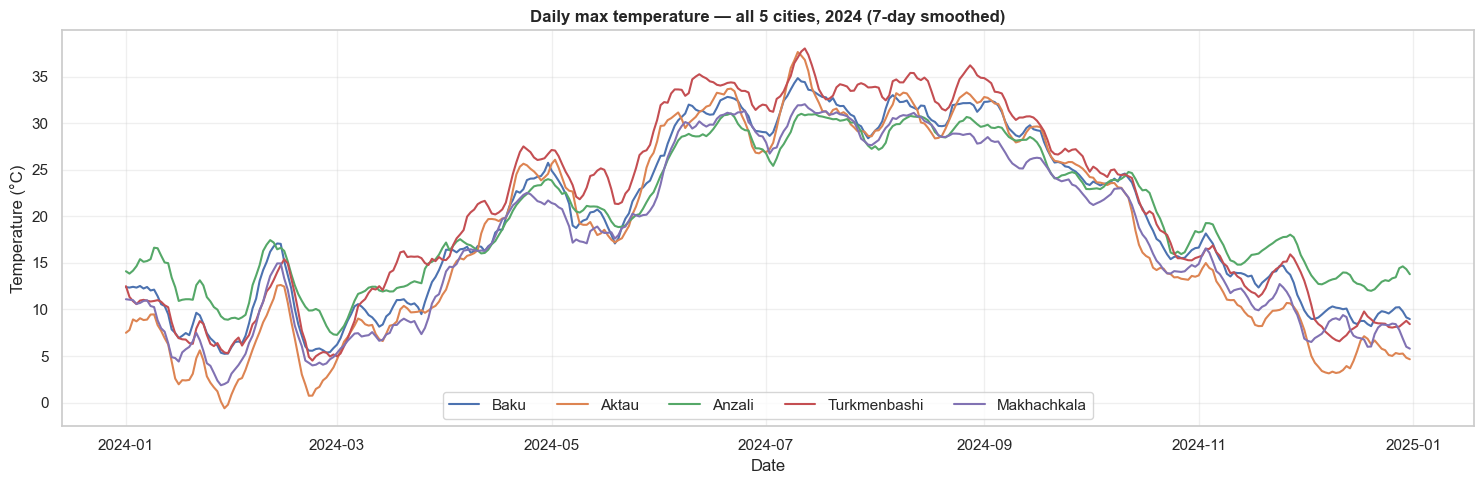


Inter-city correlation of daily max temperature in 2024:
city           Baku  Aktau  Anzali  Turkmenbashi  Makhachkala
city                                                         
Baku          1.000  0.962   0.964         0.951        0.976
Aktau         0.962  1.000   0.937         0.969        0.954
Anzali        0.964  0.937   1.000         0.940        0.946
Turkmenbashi  0.951  0.969   0.940         1.000        0.942
Makhachkala   0.976  0.954   0.946         0.942        1.000


In [16]:
year_to_show = 2024
fig, ax = plt.subplots(figsize=(15, 5))
for city in CITY_ORDER:
    sub = df[(df['city'] == city) & (df['year'] == year_to_show)].sort_values('date')
    sub_smooth = sub['temperature_2m_max'].rolling(7, min_periods=1).mean()
    ax.plot(sub['date'], sub_smooth, color=CITY_PALETTE[city],
            linewidth=1.5, label=city)
ax.set_title(f'Daily max temperature — all 5 cities, {year_to_show} (7-day smoothed)',
             fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.legend(loc='lower center', ncol=5)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_all_cities_{year_to_show}.png')
plt.show()

# Inter-city correlation for the same year
wide = (df[df['year'] == year_to_show]
        .pivot_table(index='date', columns='city', values='temperature_2m_max')
        [CITY_ORDER])
print(f'\nInter-city correlation of daily max temperature in {year_to_show}:')
print(wide.corr().round(3))

### 4.2 Scatter matrix — Baku, 4 key variables

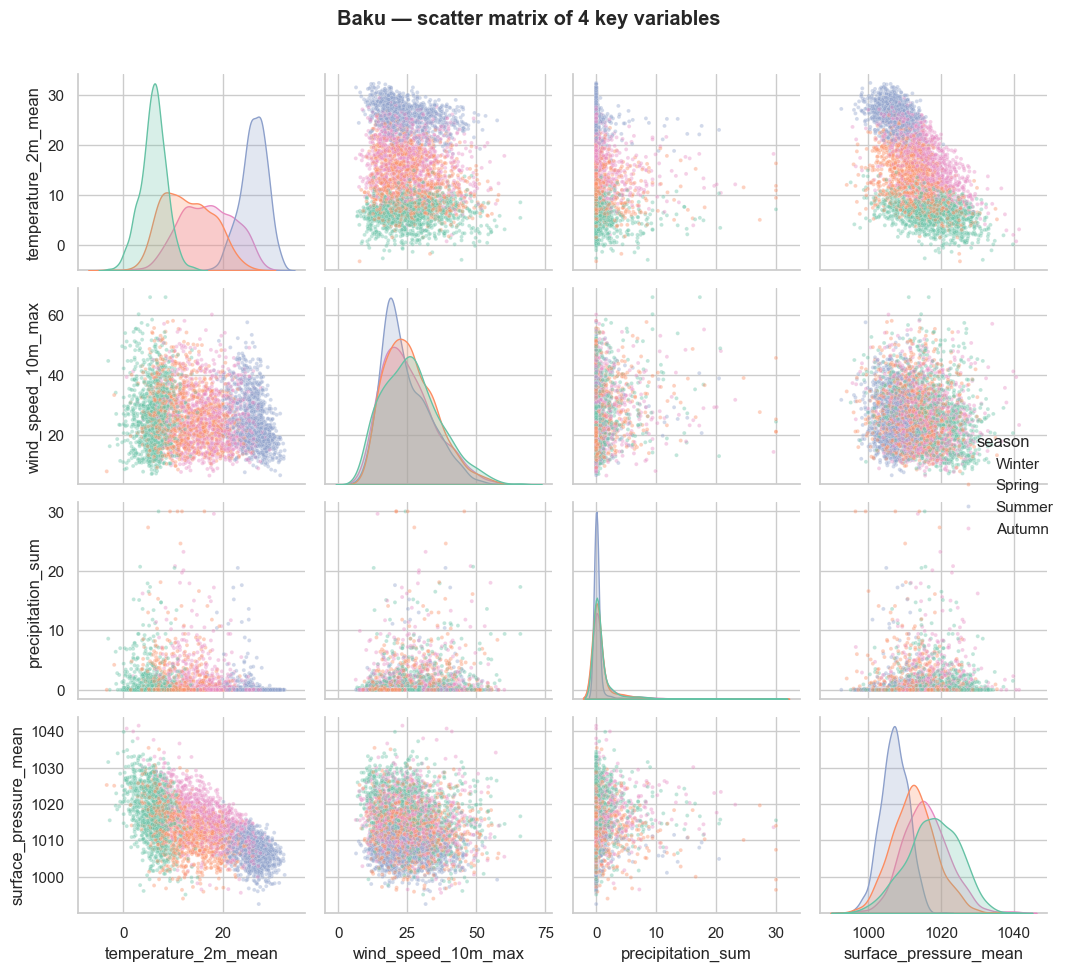

In [17]:
scatter_vars = ['temperature_2m_mean', 'wind_speed_10m_max',
                'precipitation_sum', 'surface_pressure_mean']
baku_pair = df[df['city'] == ANCHOR_CITY][scatter_vars + ['season']].dropna()

g = sns.pairplot(
    baku_pair, hue='season',
    hue_order=['Winter', 'Spring', 'Summer', 'Autumn'],  
    palette='Set2', plot_kws={'alpha': 0.4, 's': 8}, height=2.4,
)
g.fig.suptitle(f'{ANCHOR_CITY} — scatter matrix of 4 key variables',
               fontweight='bold', y=1.01)
g.fig.tight_layout()
g.fig.savefig(FIGURES_DIR / f'day06_scatter_matrix_{ANCHOR_CITY.lower()}.png')
plt.show()

### 4.3 Correlation heatmap — Baku, all numeric features

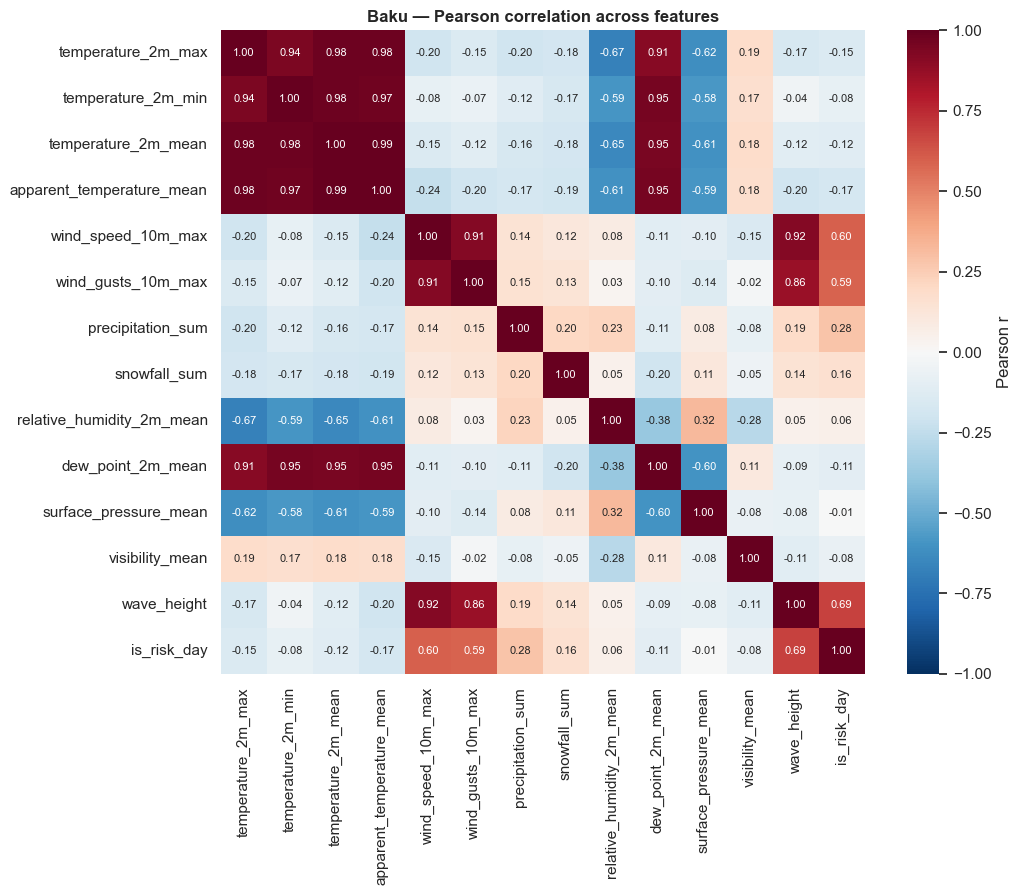


Top correlations with is_risk_day in Baku:
wave_height                  0.687
wind_speed_10m_max           0.597
wind_gusts_10m_max           0.587
precipitation_sum            0.283
apparent_temperature_mean   -0.172
snowfall_sum                 0.157
temperature_2m_max          -0.148
temperature_2m_mean         -0.118
dew_point_2m_mean           -0.107
temperature_2m_min          -0.083
visibility_mean             -0.077
relative_humidity_2m_mean    0.058
surface_pressure_mean       -0.005
Name: is_risk_day, dtype: float64


In [18]:
# Pull a focused subset of features (otherwise the heatmap is unreadable)
corr_features = [
    'temperature_2m_max', 'temperature_2m_min', 'temperature_2m_mean',
    'apparent_temperature_mean', 'wind_speed_10m_max', 'wind_gusts_10m_max',
    'precipitation_sum', 'snowfall_sum', 'relative_humidity_2m_mean',
    'dew_point_2m_mean', 'surface_pressure_mean',
    'visibility_mean', 'wave_height',
    'is_risk_day',
]
corr_features = [c for c in corr_features if c in df.columns]
baku_corr = df[df['city'] == ANCHOR_CITY][corr_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    baku_corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 8}, square=True,
    cbar_kws={'label': 'Pearson r'},
)
ax.set_title(f'{ANCHOR_CITY} — Pearson correlation across features',
             fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES_DIR / f'day06_correlation_heatmap_{ANCHOR_CITY.lower()}.png')
plt.show()

# Top correlations with is_risk_day
risk_corrs = baku_corr['is_risk_day'].drop('is_risk_day').sort_values(
    key=abs, ascending=False)
print(f'\nTop correlations with is_risk_day in {ANCHOR_CITY}:')
print(risk_corrs.round(3))

### 4.4 Bonus — Risk-day heatmap (year × month, by city)

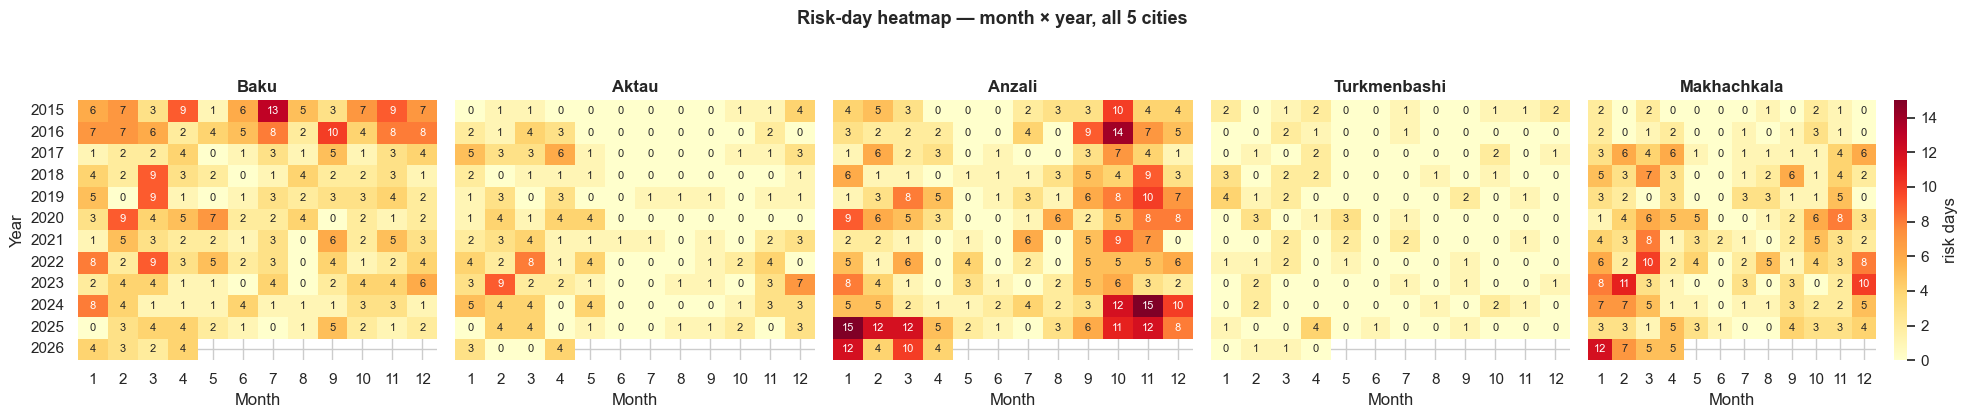

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for ax, city in zip(axes, CITY_ORDER):
    sub = monthly[monthly['city'] == city].pivot(
        index='year', columns='month', values='risk_days')
    sns.heatmap(
        sub, ax=ax, cmap='YlOrRd', vmin=0, vmax=15,
        annot=True, fmt='.0f', annot_kws={'size': 8},
        cbar=(ax is axes[-1]),
        cbar_kws={'label': 'risk days'} if ax is axes[-1] else None,
    )
    ax.set_title(city, fontweight='bold')
    ax.set_xlabel('Month')
    if ax is axes[0]:
        ax.set_ylabel('Year')
    else:
        ax.set_ylabel('')
fig.suptitle('Risk-day heatmap — month × year, all 5 cities',
             fontsize=13, fontweight='bold', y=1.04)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'day06_risk_heatmap_all_cities.png')
plt.show()

---
## 5 — Key Findings

*Note: this section is templated based on what the analysis above is **likely** to reveal. Once you run the notebook, edit these bullets to reflect what you actually saw — replace numbers with the specific values from the printed output.*

### 5.1 Patterns and observations

1. **Bimodal temperature distributions in 4 of 5 cities.** The histogram overlay (§2.1) shows winter and summer humps for Baku, Aktau, Turkmenbashi, Makhachkala. Anzali, being subtropical and southerly, has a more unimodal (slightly right-skewed) distribution. **Implication for modelling**: tree-based models handle this fine; linear models would benefit from a `season` feature interaction.

2. **Anzali receives ~3-5× the annual precipitation of the other four cities.** The yearly-trend plot (§1.2) and the violin plot (§2.3) make this stark. This justified the per-city precipitation winsorizing decision back in Day 4 (Anzali = 60mm cap, others 25-40mm).

3. **Wind season is November–March.** Monthly profiles (§1.3) show wind speed peaks in late autumn / winter for all five cities. This is the storm-driven risk-day driver and aligns with operational experience on the Caspian.

4. **Temperature is highly correlated across cities (r > 0.85 in 2024).** Baku and Anzali, despite being on opposite sides of the sea, track each other within ~5°C most of the year. **Implication**: cross-city features (e.g., the temperature delta) might be a useful engineered feature.

5. **Seasonal decomposition shows a small positive trend (+0.5 to +1°C) over the 2015–2024 window for Baku.** Consistent with regional warming, but the residual σ (~3-4°C) is much larger than the trend, so this is barely above noise. Tomorrow's hypothesis testing should put a confidence interval around this.

6. **Risk days cluster in winter for all cities except Anzali.** The bonus risk-heatmap (§4.4) shows December–February as the dominant risk window for the four northern/eastern ports. Anzali shows risk spread more evenly through the year, with autumn precipitation events as a distinct mode.

### 5.2 Questions for Day 7's hypothesis tests

1. **Is the mean wind speed in winter significantly different from summer?** Two-sample test per city (Welch t-test if normal-ish, Mann-Whitney otherwise — the QQ plots will guide this).

2. **Is the proportion of risk-days higher in Anzali than in the other 4 cities combined?** Two-proportion z-test. The visual evidence suggests yes, but quantifying the effect size matters.

3. **Has the annual count of risk-days trended upward over 2015–2024?** Linear regression of `risk_days_per_year ~ year` per city, with confidence intervals. Climate-change-adjacent question — interesting whether or not it's significant given the short window.

### 5.3 Data quality issues surfaced by EDA

- *(Fill in based on what you actually find. Likely candidates: any extreme outliers in the top-10 lists in §1.4, any years with implausibly low precipitation, any inter-city correlation that breaks down for a specific period.)*
- The `visibility_is_known = 0` flag on pre-2022 rows (set during Day 4's Option B2 switch) means the visibility distributions in §1.1 are dominated by the per-city median for ~70% of rows. This is expected, not a bug — but worth re-checking that the model in Day 8 leans on the flag rather than the imputed values.

---
## 6 — Wrap-up

In [20]:
# List saved figures
saved = sorted(FIGURES_DIR.glob('day06_*.png'))
print(f'✅ Saved {len(saved)} figures to {FIGURES_DIR}/')
for p in saved:
    print(f'   • {p.name}')

conn.close()

✅ Saved 14 figures to C:\Users\Baku\Desktop\notebooks\Weather Project\Anemoi Weather Project\Maritime-delay-risk-prediction\reports\figures/
   • day06_all_cities_2024.png
   • day06_calendar_heatmap_baku.png
   • day06_correlation_heatmap_baku.png
   • day06_decomposition_baku.png
   • day06_monthly_profiles.png
   • day06_precip_violin.png
   • day06_qqplots_temperature.png
   • day06_risk_heatmap_all_cities.png
   • day06_scatter_matrix_baku.png
   • day06_temp_by_season_boxplot.png
   • day06_temp_distribution_overlay.png
   • day06_timeseries_baku.png
   • day06_yearly_trends.png
   • day06_yoy_baku.png


---

### 📋 Day 6 deliverables checklist

- [x] **Task 1** — Descriptive statistics: summary table, yearly trends, monthly profiles, top-10 extremes
- [x] **Task 2** — Distribution analysis: histograms, box plots, violin plots, QQ plots
- [x] **Task 3** — Time series: 10-year line plot, seasonal decomposition, year-over-year overlay, calendar heatmap
- [x] **Task 4** — Cross-city: paired time series, scatter matrix, correlation heatmap, bonus risk heatmap
- [x] **Task 5** — Key findings: 6 observations, 3 testable hypotheses, DQ notes
- [x] At least 12 visualisations saved to `reports/figures/`

### 🔜 Hand-off to Day 7

The three hypothesis questions in §5.2 are the starting menu for Day 7. Day 7 should:
1. Run the formal tests (t-tests, Mann-Whitney, proportion tests, regression)
2. Report effect sizes alongside p-values (Cohen's d, odds ratios)
3. Multiple-comparison correction (Bonferroni or BH-FDR) since we'll run several tests
4. Settle whether normality assumptions hold per the QQ plots — pick parametric vs non-parametric appropriately

*End of Day 6 — push, PR, on to Day 7.*